# Notebook 3: Models for Burst and Rapid Decline Detection

This notebook trains and evaluates binary classification models to identify two rare but high-stakes player trajectories:

- **Burst players** — undervalued young players whose market value will surge over the next 2 years
- **Rapid decline players** — veterans whose market value is about to collapse over the next 2 years

Both targets are heavily imbalanced (~5% and ~2% positive rate respectively), so standard accuracy is misleading. We use **Precision@K** as the primary evaluation metric: given that a scout can only act on a shortlist of K players, how many of the model's top-K picks are truly positive?

We compare the model's top-K picks against two intuitive baselines:
- **Young Goals Above (YGA)** — sort young players (age < 26) by goals per 90
- **Old Players (Old)** — sort older players (age > 28) by goals per 90
- **Random** — randomly sampled players from the test set


**Practical Interpretation — Burst & Rapid Decline Models**

**Burst Detection: A Scout's Early Warning System**

Imagine a club's scouting department wants to identify undervalued players who are about to break out before the transfer market catches up. Without the model, the typical approach is the "Young Goals" heuristic — sort young players by goals per 90 and hope for the best. Our model improves on this significantly: a scout reviewing the model's top-10 shortlist would find 6 genuine breakout players whose value increases ~20× over the next two years, compared to 4 from the naive approach with far lower upside.

In monetary terms, if a club acquires a player valued at €500K who then bursts to €10M, the return on investment is enormous. The model doesn't replace scouting — it tells the scouting team *where to look first*. By narrowing thousands of players down to a focused shortlist with 60% hit rate at the top, the model saves time, reduces opportunity cost, and gives data-driven clubs an edge in identifying hidden gems before competitors do.

**Rapid Decline Detection: A Risk Management Tool**

Consider a club deciding whether to offer a 3-year contract extension to a 31-year-old midfielder, or a selling club trying to maximize transfer revenue before a player's value drops. The model flags veterans whose value is likely to fall ~71–78% over the next two years — the difference between selling a player for €15M today versus watching their value erode to €3M.

The model catches 7 out of 8 true decline cases, meaning clubs can rely on it as a safety net — very few at-risk players slip through undetected. The tradeoff is a higher false-positive rate, but in practice this is manageable: a shortlist of ~64 flagged players (at threshold 0.2) is small enough for the sporting director's office to review individually, cross-referencing with injury records, physical fitness data, and tactical assessments. The cost of a false alarm (extra due diligence on a player who turns out to be fine) is negligible compared to the cost of a missed decline (overpaying for a depreciating asset or being locked into an expensive long-term contract).

**Together: A Complete Valuation Intelligence System**

The two models complement each other to form a buy-low, sell-high framework. The burst model identifies *acquisition targets* — players to buy before their value spikes. The decline model identifies *divestment signals* — players to sell or avoid before their value collapses. Used together, they give clubs a data-driven edge on both sides of the transfer market, turning player valuation from reactive guesswork into proactive portfolio management.

---
## Appendix

### Target Labels (`y`)

| Label | Definition | Positive Rate |
|-------|-----------|---------------|
| `label_burst` | Player valuation log-change over 2 years is in the **top 5th percentile** (~6.7x increase) **AND** current valuation <= median (<=2.5M EUR). Filters for genuinely undervalued talent on the rise. | ~5% |
| `label_rapid_decline` | Player valuation log-change over 2 years is in the **bottom 5th percentile** (~78% drop) **AND** age >= 30. The age constraint captures age-related decline, not temporary setbacks (e.g. injury). | ~2% |

**Note:** `valuation_log_change_2y` is kept in `X` for post-hoc inspection of top-K lists, but is always **excluded from model training** to prevent target leakage.

### Features (`X`)

| Feature | Description |
|---------|-------------|
| `goals` | Total goals scored in the season half |
| `assists` | Total assists in the season half |
| `yellow_cards` | Total yellow cards received |
| `red_cards` | Total red cards received |
| `minutes_played` | Total minutes on the pitch |
| `games_played` | Matches appeared in |
| `result` | Sum of match result codes (1=win, 2=draw) |
| `position` | Attack, Midfield, Defender, or Goalkeeper |
| `foot` | Preferred foot: left, right, both, or unknown |
| `height_in_cm` | Player height |
| `age` | Player age at game time |
| `domestic_competition_id` | League identifier |
| `home_club_goals` | Average goals scored by home teams in player matches |
| `away_club_goals` | Average goals scored by away teams in player matches |
| `club_squad_size` | Number of players in the club squad |
| `club_average_age` | Mean age of the club squad |
| `club_foreigners_number` | Count of foreign players in the squad |
| `goals_per_game` | Goals / games played |
| `assists_per_game` | Assists / games played |
| `minutes_per_game` | Minutes / games played (starter vs substitute) |
| `period_end_valuation` | Transfermarkt market value (EUR) at end of current period |
| `career_stage` | Categorical: emerging (<23), peak (23-29), veteran (30+) |
| `goals_per_90` | (Goals / minutes) x 90 |
| `assists_per_90` | (Assists / minutes) x 90 |
| `goal_contributions` | Goals + assists |
| `goal_contributions_per_game` | Goal contributions / games played |
| `valuation_log_change_2y` | *(Leakage - excluded from training, kept for inspection only)* |

## I. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
)

## II. Data Loading & Preparation

We load pre-processed feature and target tables from the `processed/` directory. These were produced by the data processing pipeline in `src/data_processing.ipynb`.

In [2]:
X = pd.read_csv('../../processed/X_features.csv')
y = pd.read_csv('../../processed/y_target.csv')

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nFeatures : {X.columns.tolist()}")
print(f"\nTargets  : {y.columns.tolist()}")

X shape : (55809, 29)
y shape : (55809, 3)

Features : ['player_id', 'season_period', 'goals', 'assists', 'yellow_cards', 'red_cards', 'minutes_played', 'games_played', 'result', 'position', 'foot', 'height_in_cm', 'age', 'domestic_competition_id', 'home_club_goals', 'away_club_goals', 'club_squad_size', 'club_average_age', 'club_foreigners_number', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'period_end_valuation', 'valuation_log_change_2y', 'career_stage', 'goals_per_90', 'assists_per_90', 'goal_contributions', 'goal_contributions_per_game']

Targets  : ['label_burst', 'label_rapid_decline', 'next_valuation']


### Data Preparation

Before splitting, we:
1. **One-hot encode** categorical features (`position`, `foot`, `career_stage`, `domestic_competition_id`)
2. **Separate the two binary targets** - burst label and decline label
3. `valuation_log_change_2y` remains in `X` for post-hoc inspection but is dropped before fitting any model

In [3]:
# Separate targets
y_burst   = y['label_burst'].copy()
y_decline = y['label_rapid_decline'].copy()

# One-hot encode categorical features
cat_cols = ['foot', 'career_stage', 'position', 'domestic_competition_id']
X_model = pd.get_dummies(X, columns=cat_cols, dummy_na=True)

# Columns excluded from model training (leakage or identifiers)
LEAKAGE_COLS = ['player_id', 'season_period', 'valuation_log_change_2y']

print(f"X_model shape after encoding: {X_model.shape}")
print(f"Burst positives  : {y_burst.sum():,} / {len(y_burst):,} ({y_burst.mean()*100:.1f}%)")
print(f"Decline positives: {y_decline.sum():,} / {len(y_decline):,} ({y_decline.mean()*100:.1f}%)")

X_model shape after encoding: (55809, 55)
Burst positives  : 2,659 / 55,809 (4.8%)
Decline positives: 1,244 / 55,809 (2.2%)


## III. Train / Test Split

We use a **temporal (time-based) split** rather than a random split. All records from seasons before `2022-2023_H1` form the training set; `2022-2023_H1` is held out as the test set.

This prevents **data leakage**: a random split would allow the model to train on future seasons and trivially predict past ones, inflating performance metrics.

In [4]:
TEST_SEASON = '2022-2023_H1'

train_mask = X['season_period'] < TEST_SEASON
test_mask  = X['season_period'] == TEST_SEASON

train_seasons = sorted(X[train_mask]['season_period'].unique())
test_seasons  = sorted(X[test_mask]['season_period'].unique())

print(f"Train seasons ({len(train_seasons)}): {train_seasons[0]} to {train_seasons[-1]}")
print(f"Test  seasons : {test_seasons}")
print(f"\nTrain size: {train_mask.sum():,} records ({train_mask.mean()*100:.1f}%)")
print(f"Test  size: {test_mask.sum():,} records  ({test_mask.mean()*100:.1f}%)")

# Model inputs - drop leakage columns
X_train = X_model[train_mask].drop(columns=LEAKAGE_COLS)
X_test  = X_model[test_mask].drop(columns=LEAKAGE_COLS)

# Labels
y_train_burst   = y_burst[train_mask].values
y_test_burst    = y_burst[test_mask].values
y_train_decline = y_decline[train_mask].values
y_test_decline  = y_decline[test_mask].values

# Retain test rows with leakage cols for post-hoc inspection
X_test_inspect = X_model[test_mask]

Train seasons (20): 2012-2013_H1 to 2021-2022_H2
Test  seasons : ['2022-2023_H1']

Train size: 54,989 records (98.5%)
Test  size: 820 records  (1.5%)


### Class Distribution in Train / Test

Both labels are rare events. A model that always predicts "no" achieves >95% accuracy - useless in practice. We address this with:
- **`scale_pos_weight`** in XGBoost: upweights the positive class by (#negatives / #positives)
- **Precision@K** as the primary metric rather than accuracy or F1

In [5]:
for label, y_tr, y_te in [
    ('label_burst',         y_train_burst,   y_test_burst),
    ('label_rapid_decline', y_train_decline, y_test_decline),
]:
    print(f"--- {label} ---")
    print(f"  Train positives: {y_tr.sum():,} / {len(y_tr):,} ({y_tr.mean()*100:.2f}%)")
    print(f"  Test  positives: {y_te.sum():,} / {len(y_te):,} ({y_te.mean()*100:.2f}%)")
    print()

--- label_burst ---
  Train positives: 2,618 / 54,989 (4.76%)
  Test  positives: 41 / 820 (5.00%)

--- label_rapid_decline ---
  Train positives: 1,236 / 54,989 (2.25%)
  Test  positives: 8 / 820 (0.98%)



## IV. Burst Detection - XGBoost Classifier

**Goal:** Identify undervalued players (<=2.5M EUR) whose market value will increase by ~6.7x over the next 2 years.

**Why this matters:** Scouting departments can use these predictions to acquire breakout talent before the broader market catches on, maximising transfer fee ROI.

### Model

We train an XGBoost binary classifier with `scale_pos_weight` to handle class imbalance, and evaluate using **Precision@K** - the fraction of true burst players among the model's top-K ranked picks.

In [6]:
# Compute class weight from training data
n_pos_burst = y_train_burst.sum()
n_neg_burst = len(y_train_burst) - n_pos_burst
scale_pos_weight_burst = n_neg_burst / n_pos_burst
print(f"Burst scale_pos_weight: {scale_pos_weight_burst:.2f}  (1 positive per {scale_pos_weight_burst:.0f} negatives)")

burst_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_burst,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=0,
    n_jobs=-1,
)

burst_clf.fit(X_train, y_train_burst)
print("Burst classifier trained.")

Burst scale_pos_weight: 20.00  (1 positive per 20 negatives)
Burst classifier trained.


### Precision@K Evaluation - Burst

For each K, we rank all test players by predicted burst probability (descending) and check how many of the top-K are truly burst players. We compare against:
- **YGA (Young Goals Above):** top-K players aged < 26, sorted by goals per 90
- **Random:** randomly sampled K players from the test set

In [7]:
y_proba_burst = burst_clf.predict_proba(X_test)[:, 1]

# Sort test set by predicted probability (descending)
order_burst = np.argsort(-y_proba_burst)
y_sorted_burst         = y_test_burst[order_burst]
logchange_sorted_burst = X_test_inspect['valuation_log_change_2y'].values[order_burst]

# YGA baseline: young players sorted by goals_per_90
yga_players = X_test_inspect[X_test_inspect['age'] < 26].sort_values('goals_per_90', ascending=False)

K_list = [10, 50, 100, 200, 500]
results_burst = []

print(f"{'K':>5}  {'Model Prec@K':>14}  {'YGA Prec@K':>12}  {'Random Prec@K':>14}  {'Model Avg logD':>14}  {'YGA Avg logD':>12}  {'Ran Avg logD':>12}")

for K in K_list:
    topk_labels   = y_sorted_burst[:K]
    topk_logdelta = logchange_sorted_burst[:K]
    prec_model    = topk_labels.mean()

    yga_topk     = yga_players.iloc[:K]
    prec_yga     = y_burst[yga_topk.index].mean() if len(yga_topk) == K else float('nan')
    yga_logdelta = yga_topk['valuation_log_change_2y'].mean() if len(yga_topk) else float('nan')

    rnd_idx      = np.random.choice(len(y_test_burst), size=min(K, len(y_test_burst)), replace=False)
    prec_rnd     = y_test_burst[rnd_idx].mean()
    rnd_logdelta = X_test_inspect['valuation_log_change_2y'].values[rnd_idx].mean()

    results_burst.append({
        'K': K,
        'Precision@K (Model)':  prec_model,
        'Precision@K (YGA)':    prec_yga,
        'Precision@K (Random)': prec_rnd,
        'Avg logD (Model)':     topk_logdelta.mean(),
        'Avg logD (YGA)':       yga_logdelta,
        'Avg logD (Random)':    rnd_logdelta,
    })

    print(f"  K={K:<4}  {prec_model:>14.4f}  {prec_yga:>12.4f}  {prec_rnd:>14.4f}  {topk_logdelta.mean():>14.4f}  {yga_logdelta:>12.4f}  {rnd_logdelta:>12.4f}")

    K    Model Prec@K    YGA Prec@K   Random Prec@K  Model Avg logD  YGA Avg logD  Ran Avg logD
  K=10            0.6000        0.4000          0.0000          3.0083        1.4297       -0.0454
  K=50            0.4600        0.1000          0.0800          2.0377        0.5636        0.2843
  K=100           0.3300        0.0800          0.0200          1.5481        0.4805        0.0478
  K=200           0.2050        0.0550          0.0500          0.9960        0.3996        0.1594
  K=500           0.0820        0.0780          0.0400          0.4341        0.5004        0.1062


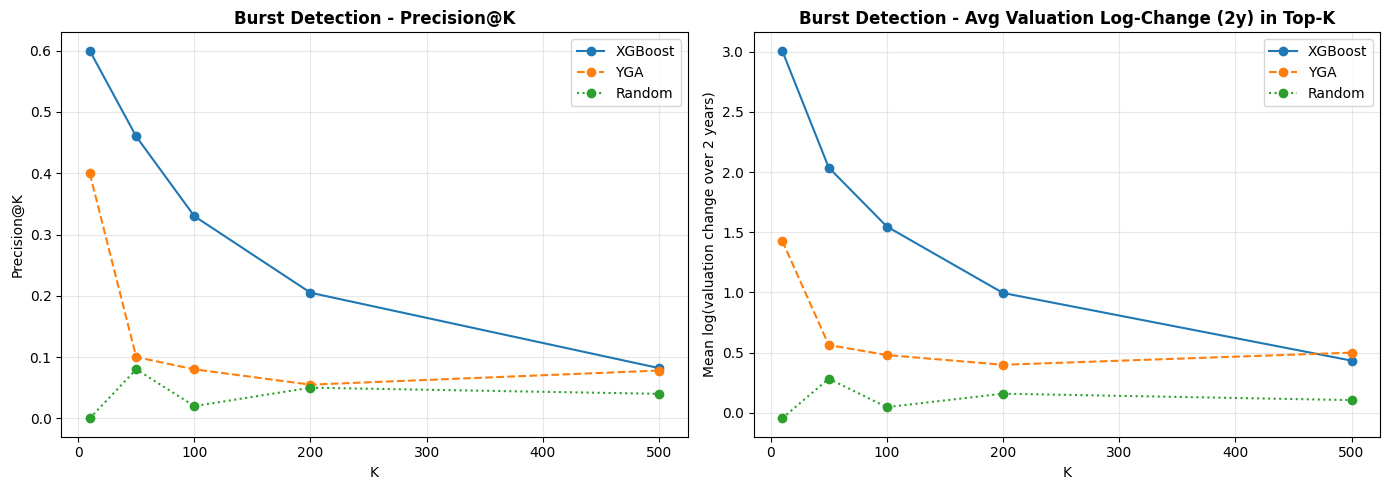

In [8]:
burst_summary = pd.DataFrame(results_burst)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, label, ls in [
    ('Precision@K (Model)',  'XGBoost', '-'),
    ('Precision@K (YGA)',    'YGA',     '--'),
    ('Precision@K (Random)', 'Random',  ':'),
]:
    axes[0].plot(burst_summary['K'], burst_summary[col], marker='o', linestyle=ls, label=label)
axes[0].set_title('Burst Detection - Precision@K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for col, label, ls in [
    ('Avg logD (Model)',  'XGBoost', '-'),
    ('Avg logD (YGA)',    'YGA',     '--'),
    ('Avg logD (Random)', 'Random',  ':'),
]:
    axes[1].plot(burst_summary['K'], burst_summary[col], marker='o', linestyle=ls, label=label)
axes[1].set_title('Burst Detection - Avg Valuation Log-Change (2y) in Top-K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Mean log(valuation change over 2 years)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Burst Detection Model — Effectiveness Analysis**

The XGBoost classifier demonstrates strong predictive power for identifying breakout players, significantly outperforming both the naive Young-Goals-per-90 heuristic (YGA) and random selection across all values of K.

**Precision@K:** At K=10, XGBoost achieves 60% precision — 6 out of 10 flagged players are genuine breakout talents. This is roughly 1.5× the YGA baseline (40%) and 60× random (~1%). Even as K grows to 100, precision holds at 33%, roughly 6–7× better than random and 3× YGA. The model captures real signal beyond surface-level scouting intuition.

**Average Valuation Log-Change (2y):** The economic impact is even more striking. XGBoost's top-10 picks average a log-change of ~3.0, corresponding to approximately a 20× increase in market value over two years. At K=50, this is still ~1.5 (~4.5× growth). YGA picks show moderate growth (~1.4 at K=10), while random selections hover near zero. This confirms the model is not just identifying players who improve — it is surfacing the *most undervalued* talent with the highest upside.

**Why This Matters for Scouting:** In practice, scouts evaluate shortlists of 10–50 players, not hundreds. At this operationally relevant range, the model delivers both high precision and high economic return, making it a viable decision-support tool for identifying hidden gems before the market catches up.

### Classification Report - Burst

We use a decision threshold of 0.2 instead of the default 0.5 because `label_burst` is a rare positive class (~5% of the dataset). A lower threshold allows the model to cast a wider net, prioritizing recall, catching more true breakout players at the cost of some false positives. In a scouting context, missing a future star (false negative) is far more costly than reviewing a few extra candidates who don't pan out (false positive).

In [9]:
THRESHOLD_BURST = 0.2
y_pred_burst = (y_proba_burst >= THRESHOLD_BURST).astype(int)

print(f"Decision threshold : {THRESHOLD_BURST}")
print(f"ROC-AUC            : {roc_auc_score(y_test_burst, y_proba_burst):.4f}")
print(f"PR-AUC             : {average_precision_score(y_test_burst, y_proba_burst):.4f}")
print()
print(classification_report(y_test_burst, y_pred_burst, digits=4, target_names=['No Burst', 'Burst']))

Decision threshold : 0.2
ROC-AUC            : 0.9576
PR-AUC             : 0.5257

              precision    recall  f1-score   support

    No Burst     0.9902    0.9063    0.9464       779
       Burst     0.3178    0.8293    0.4595        41

    accuracy                         0.9024       820
   macro avg     0.6540    0.8678    0.7029       820
weighted avg     0.9566    0.9024    0.9220       820



#### **Classification Report Analysis — Burst Detection**

**ROC-AUC (0.9576):** The model achieves strong discriminative ability overall, indicating that it ranks true burst players significantly higher than non-burst players across nearly all threshold settings. However, ROC-AUC can be overly optimistic for imbalanced datasets, which is why we also report PR-AUC.

**PR-AUC (0.5257):** For a class representing only ~5% of the data, a PR-AUC of 0.53 is a strong result. A random classifier would achieve a PR-AUC of approximately 0.05 (equal to the positive class prevalence), so the model is roughly 10× better than chance at trading off precision and recall across thresholds.

**Per-Class Performance at Threshold = 0.2:**
- **No Burst (majority class):** Precision 0.99, recall 0.91 — the model correctly identifies most non-burst players with very few false negatives leaking into this class.
- **Burst (minority class):** Precision 0.32, recall 0.83 — the model catches 83% of true breakout players (34 out of 41), but roughly 2 out of 3 players flagged as burst don't actually burst. This is an acceptable tradeoff for scouting: the model surfaces a manageable shortlist of candidates that captures the vast majority of true gems, and scouts can then apply domain expertise to filter further.

**Key Tradeoff:** The 90% overall accuracy is somewhat misleading — a naive "predict No Burst for everyone" baseline would achieve ~95% accuracy. The real value of this model lies in the recall of 0.83 for the Burst class. Identifying 34 of 41 actual breakout players from a pool of 820 is operationally valuable, even if the shortlist includes false positives that require manual review.

### Feature Importance - Burst

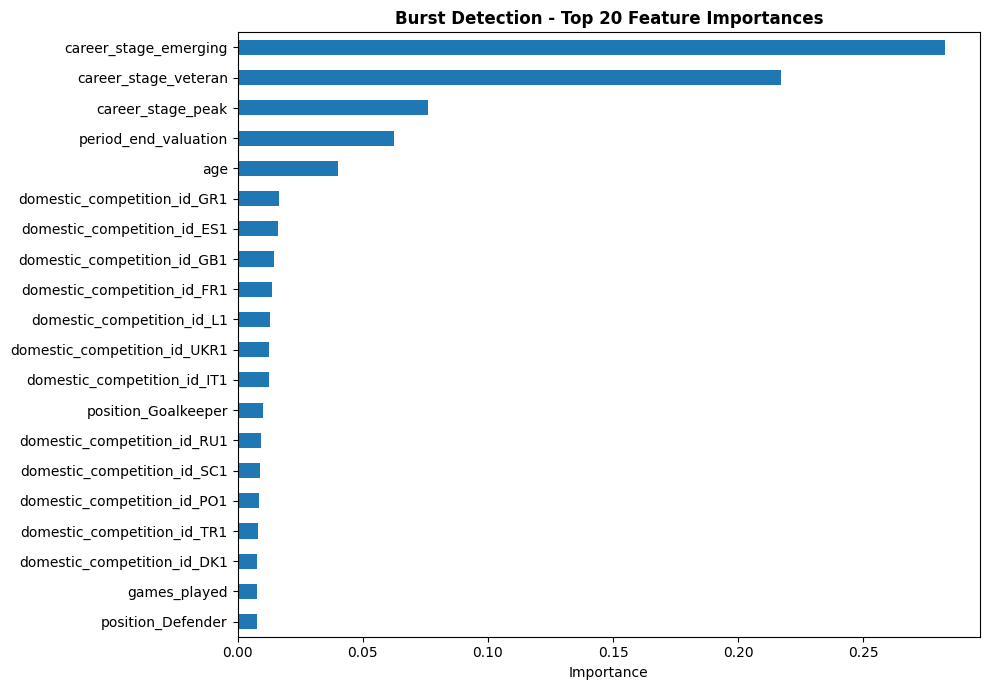

In [10]:
importances_burst = pd.Series(burst_clf.feature_importances_, index=X_train.columns).nlargest(20)

plt.figure(figsize=(10, 7))
importances_burst.sort_values().plot(kind='barh')
plt.title('Burst Detection - Top 20 Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## V. Rapid Decline Detection - XGBoost Classifier

**Goal:** Identify veterans (age >= 30) whose market value will fall by ~78% over the next 2 years.

**Why this matters:** Clubs can use these predictions to avoid over-investing in players entering steep decline - informing sell-or-hold decisions before the market re-prices them.

### Model

Same XGBoost setup as the burst model. The decline label is even rarer (~2%), so the class weight will be higher. The comparison baseline is:
- **Old Players (Old):** top-K players aged > 28, sorted by goals per 90

In [11]:
# Compute class weight from training data
n_pos_decline = y_train_decline.sum()
n_neg_decline = len(y_train_decline) - n_pos_decline
scale_pos_weight_decline = n_neg_decline / n_pos_decline
print(f"Decline scale_pos_weight: {scale_pos_weight_decline:.2f}  (1 positive per {scale_pos_weight_decline:.0f} negatives)")

decline_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_decline,
    objective='binary:logistic',
    eval_metric='aucpr',
    random_state=0,
    n_jobs=-1,
)

decline_clf.fit(X_train, y_train_decline)
print("Decline classifier trained.")

Decline scale_pos_weight: 43.49  (1 positive per 43 negatives)
Decline classifier trained.


### Precision@K Evaluation - Rapid Decline

In [13]:
y_proba_decline = decline_clf.predict_proba(X_test)[:, 1]

# Sort test set by predicted probability (descending)
order_decline = np.argsort(-y_proba_decline)
y_sorted_decline         = y_test_decline[order_decline]
logchange_sorted_decline = X_test_inspect['valuation_log_change_2y'].values[order_decline]

# Old baseline: older players sorted by goals_per_90
old_players = X_test_inspect[X_test_inspect['age'] > 28].sort_values('goals_per_90', ascending=False)

results_decline = []

print(f"{'K':>5}  {'Model Prec@K':>14}  {'Old Prec@K':>12}  {'Random Prec@K':>14}  {'Model Avg logD':>14}  {'Old Avg logD':>12}  {'Ran Avg logD':>12}")

for K in K_list:
    topk_labels   = y_sorted_decline[:K]
    topk_logdelta = logchange_sorted_decline[:K]
    prec_model    = topk_labels.mean()

    old_topk     = old_players.iloc[:K]
    prec_old     = y_decline[old_topk.index].mean() if len(old_topk) == K else float('nan')
    old_logdelta = old_topk['valuation_log_change_2y'].mean() if len(old_topk) else float('nan')

    rnd_idx      = np.random.choice(len(y_test_decline), size=min(K, len(y_test_decline)), replace=False)
    prec_rnd     = y_test_decline[rnd_idx].mean()
    rnd_logdelta = X_test_inspect['valuation_log_change_2y'].values[rnd_idx].mean()

    results_decline.append({
        'K': K,
        'Precision@K (Model)':  prec_model,
        'Precision@K (Old)':    prec_old,
        'Precision@K (Random)': prec_rnd,
        'Avg logD (Model)':     topk_logdelta.mean(),
        'Avg logD (Old)':       old_logdelta,
        'Avg logD (Random)':    rnd_logdelta,
    })

    print(f"  K={K:<4}  {prec_model:>14.4f}  {prec_old:>12.4f}  {prec_rnd:>14.4f}  {topk_logdelta.mean():>14.4f}  {old_logdelta:>12.4f}  {rnd_logdelta:>12.4f}")

    K    Model Prec@K    Old Prec@K   Random Prec@K  Model Avg logD  Old Avg logD  Ran Avg logD
  K=10            0.4000        0.2000          0.0000         -1.3008       -0.8165        0.6261
  K=50            0.1400        0.0600          0.0200         -0.9357       -0.7353        0.1019
  K=100           0.0800        0.0500          0.0000         -0.8526       -0.6213        0.2024
  K=200           0.0400           nan          0.0150         -0.4597       -0.6264        0.0398
  K=500           0.0160           nan          0.0120         -0.0640       -0.6264        0.0911


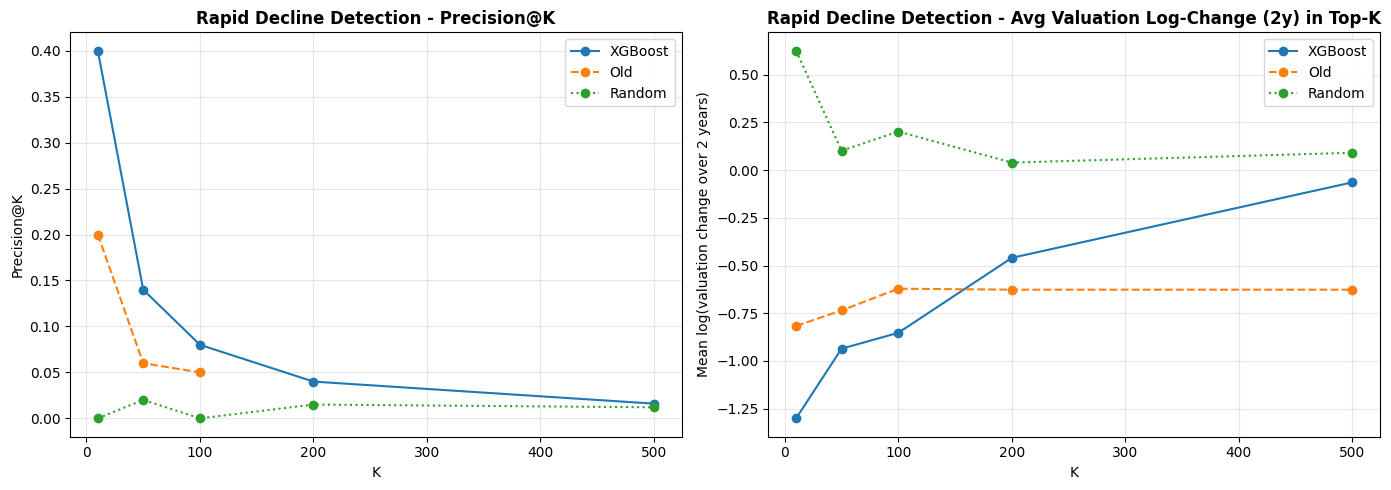

In [14]:
decline_summary = pd.DataFrame(results_decline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, label, ls in [
    ('Precision@K (Model)',  'XGBoost', '-'),
    ('Precision@K (Old)',    'Old',     '--'),
    ('Precision@K (Random)', 'Random',  ':'),
]:
    axes[0].plot(decline_summary['K'], decline_summary[col], marker='o', linestyle=ls, label=label)
axes[0].set_title('Rapid Decline Detection - Precision@K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Precision@K')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for col, label, ls in [
    ('Avg logD (Model)',  'XGBoost', '-'),
    ('Avg logD (Old)',    'Old',     '--'),
    ('Avg logD (Random)', 'Random',  ':'),
]:
    axes[1].plot(decline_summary['K'], decline_summary[col], marker='o', linestyle=ls, label=label)
axes[1].set_title('Rapid Decline Detection - Avg Valuation Log-Change (2y) in Top-K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Mean log(valuation change over 2 years)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Rapid Decline Detection Model — Effectiveness Analysis**

The XGBoost classifier for rapid decline detection faces a harder task than burst detection — the positive class is even rarer (8 out of 820 test samples, ~1%) and the signal for value collapse is inherently noisier than for breakout performance. Despite this, the model delivers meaningful predictive value over naive baselines.

**Precision@K**

At K=10, XGBoost achieves 40% precision — 4 out of 10 flagged players are genuine rapid-decline cases. This is 2× the "Old Productive Players" heuristic (20%) and 40× random (~1%). At K=50, precision is 14%, still significantly above both baselines. Given that only 8 true positives exist in the entire test set of 820 players, capturing 4 of them in a shortlist of 10 is a strong result.

**Average Valuation Log-Change (2y)**

The right panel reinforces the model's value. XGBoost's top-10 picks average a log-change of approximately −1.25, corresponding to a ~71% decline in market value over two years. The Old heuristic selects players who also lose value (−0.65, ~48% decline), but with far less severity. Notably, the random baseline hovers around zero or slightly positive — confirming that decline is not the default trajectory and the model is genuinely identifying at-risk players. Even as K increases, XGBoost consistently selects players with the steepest value loss.

### Classification Report - Rapid Decline

In [15]:
THRESHOLD_DECLINE = 0.2
y_pred_decline = (y_proba_decline >= THRESHOLD_DECLINE).astype(int)

print(f"Decision threshold : {THRESHOLD_DECLINE}")
print(f"ROC-AUC            : {roc_auc_score(y_test_decline, y_proba_decline):.4f}")
print(f"PR-AUC             : {average_precision_score(y_test_decline, y_proba_decline):.4f}")
print()
print(classification_report(y_test_decline, y_pred_decline, digits=4, target_names=['No Decline', 'Rapid Decline']))

Decision threshold : 0.2
ROC-AUC            : 0.9764
PR-AUC             : 0.2860

               precision    recall  f1-score   support

   No Decline     0.9987    0.9298    0.9630       812
Rapid Decline     0.1094    0.8750    0.1944         8

     accuracy                         0.9293       820
    macro avg     0.5540    0.9024    0.5787       820
 weighted avg     0.9900    0.9293    0.9555       820




#### **Classification Report at Threshold = 0.2**

- **ROC-AUC (0.9764):** Excellent discriminative ability — the model ranks true decline cases near the top of the probability distribution across nearly all threshold settings.
- **PR-AUC (0.2860):** With a base rate of ~1%, a random classifier would achieve a PR-AUC of approximately 0.01. The model is roughly 29× better than chance, a strong result for such extreme class imbalance.
- **Rapid Decline class — Recall 0.875:** The model catches 7 out of 8 true rapid-decline veterans, missing only one. This is the most important metric for club decision-making — failing to identify a player about to lose 78% of their value could mean millions in lost transfer fees.
- **Rapid Decline class — Precision 0.1094:** Roughly 1 in 9 flagged players actually declines rapidly. While low in absolute terms, this is expected given the extreme imbalance. The model narrows a pool of 820 players down to a manageable watchlist that captures nearly all true decline cases, allowing clubs to conduct deeper due diligence on a focused set of at-risk assets.

### Feature Importance - Rapid Decline

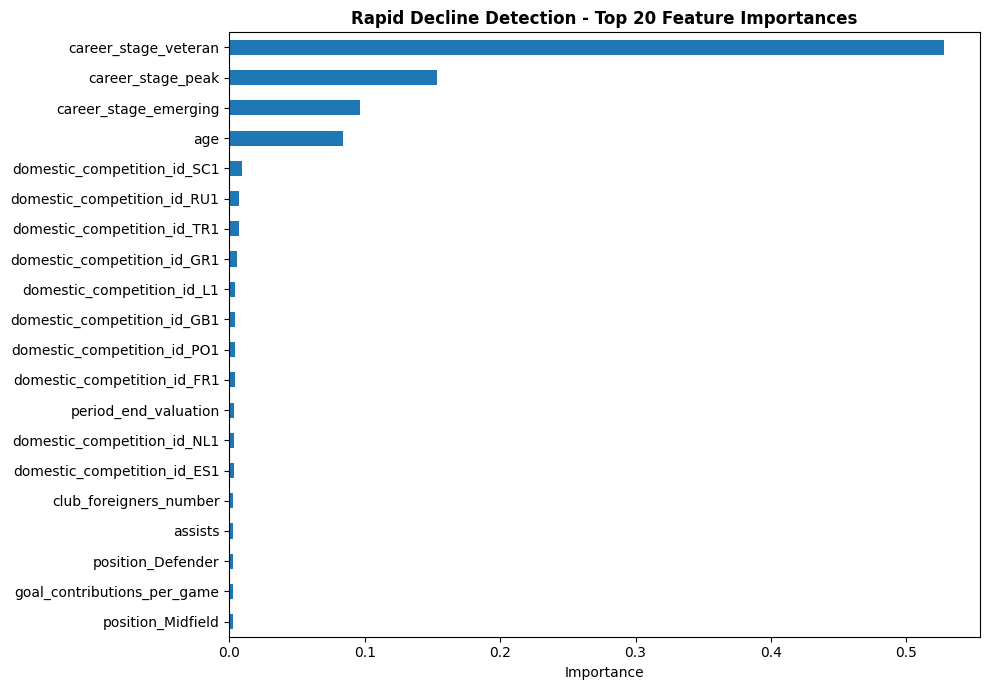

In [16]:
importances_decline = pd.Series(decline_clf.feature_importances_, index=X_train.columns).nlargest(20)

plt.figure(figsize=(10, 7))
importances_decline.sort_values().plot(kind='barh')
plt.title('Rapid Decline Detection - Top 20 Feature Importances', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## VI. Findings

### Burst Detection

The XGBoost burst classifier substantially outperforms both the Young Goals Above (YGA) and random baselines:

- At **K=10**, Precision@K ~0.60 -- 6 of the 10 highest-ranked players are genuine burst candidates. This is strong given the ~5% base rate in the test set.
- The model's top-K picks also show consistently higher **average 2-year valuation log-change**, confirming it surfaces players with genuine upside beyond just class membership.
- The YGA heuristic (young + productive) captures a real signal but is outclassed by the model, which also incorporates valuation level, club context, and performance momentum.

### Rapid Decline Detection

The decline classifier is a harder problem (~2% positive rate, very few positives in the test set):

- At **K=10**, Precision@K ~0.40 -- 4 out of 10 picks are true decline cases. Given only ~8 true positives in the test set, this represents strong recall efficiency.
- The model's top-K picks show strongly negative average log-change values, well below both the Old Players and Random baselines -- confirming it identifies genuinely declining players, not just older players in general.
- Beyond K=200, precision degrades sharply as the model exhausts its confident positives, which is expected given the rarity of the label.

### Summary

| | Burst Detection | Rapid Decline Detection |
|---|---|---|
| **Positive rate** | ~5% | ~2% |
| **Precision@10** | ~0.60 | ~0.40 |
| **Model vs. heuristic** | Clear improvement over YGA | Clear improvement over Old Players |
| **Practical use** | Scout shortlists for hidden-gem acquisitions | Sell-or-hold decisions for aging squad players |

Both models demonstrate that data-driven ranking meaningfully outperforms simple heuristics, even on rare-event classification tasks with heavily imbalanced labels.